# Eq calculation

In [32]:
from SRK import  phi_SRK, phi_SRK_VLE
import numpy as np

In [33]:
from Gmin import calc_eq, element_balance, dfg, g_T, g_T_VLE, element_balance_VLE
from EqConstant import K0_CO2_to_MeOH, K0_CO_to_MeOH, K0_WGS
import matplotlib.pyplot as plt
from PhaseStability import tpd, min_tpd, initial_guesses

In [34]:
T = np.linspace(100, 400, 100) + 273.15
#T = np.array([468, 469, 470, 471, 472, 473, 474])
p = np.array(([1, 10, 30, 50, 100])) * 1e5
x_0 = np.array([
    0.25, # CO2
    0.75-4e-10, # H2
    1e-10, # H2O
    1e-10, # CO
    1e-10, # CH3OH
    1e-10, # N2/CH4
])

'''T = np.linspace(463, 513, 20)
p = np.array(([197])) * 1e5
x_0 = np.array([
    0.035, # CO2
    0.67-2e-20, # H2
    1e-20, # H2O
    0.244, # CO
    1e-20, # CH3OH
    0.051, # N2
])'''

'''T = np.array([473])
p = np.array(([300])) * 1e5
x_0 = np.array([
    0.08, # CO2
    0.74-2e-20, # H2
    1e-20, # H2O
    0.15, # CO
    1e-20, # CH3OH
    0.03, # N2
])'''

'T = np.array([473])\np = np.array(([300])) * 1e5\nx_0 = np.array([\n    0.08, # CO2\n    0.74-2e-20, # H2\n    1e-20, # H2O\n    0.15, # CO\n    1e-20, # CH3OH\n    0.03, # N2\n])'

In [65]:
x_eq = np.zeros((len(p), len(T), 12))
n_eq = np.zeros((len(p), len(T), 12))
X_CO2 = np.zeros((len(p), len(T)))
X_H2 = np.zeros((len(p), len(T)))
S_MeOH = np.zeros((len(p), len(T)))
for i in range(len(p)):
    for j in range(len(T)):
        _, _,n_eq[i, j, :], x_eq[i, j, :] = calc_eq(T[j], p[i], x_0)
        try:
            X_CO2[i, j] = ((x_0[0] + 1e-20) - (n_eq[i, j, 0] + n_eq[i, j, 6])) / (x_0[0] + 1e-20)
            X_H2[i, j] = ((x_0[1] + 1e-20) - (n_eq[i, j, 1] + n_eq[i, j, 7])) / (x_0[1] + 1e-20)
        except IndexError:
            X_CO2[i, j] = ((x_0[0]) - (n_eq[i, j, 0])) / x_0[0]

Trivial solution found.
Trivial solution found.
Trivial solution found.
Trivial solution found.
Trivial solution found.
Trivial solution found.
Trivial solution found.


# Data postprocessing

In [68]:
K0_R1_fg = np.zeros_like(T)
K0_R2_fg = np.zeros_like(T)
K0_R3_fg = np.zeros_like(T)

for i in range(len(T)):

    K0_R1_fg[i] = K0_CO_to_MeOH(T[i])
    K0_R2_fg[i] = K0_CO2_to_MeOH(T[i])
    K0_R3_fg[i] = K0_WGS(T[i])

In [95]:
f_i = np.zeros((len(p), len(T), 12))
f_dev = np.zeros((len(p), len(T), 6))
x_dev = np.zeros((len(p), len(T), 6))

phii = np.zeros((len(p), len(T), 12))

K0_R1 = np.zeros((len(p), len(T)))
K0_R2 = np.zeros((len(p), len(T)))
K0_R3 = np.zeros((len(p), len(T)))

for i in range(len(p)):
    
    for j in range(len(T)):

        one_phase = False
        
        try:

            if not np.any(x_eq[i, j, 6:] == 0):

                phii_V, Z_V = phi_SRK(x_eq[i, j, :6], T[j], p[i])
                phii_L, Z_L = phi_SRK(x_eq[i, j, 6:], T[j], p[i])

                K_ij = phii_L / phii_V
                if np.sum(np.log(K_ij)**2) < 1e-4:
                    print("Trivial solution")
                    print(Z_L, Z_V)

                    one_phase = True



                #if Z_L > Z_V:

                # change positiion of x_eq (first 6 with last 6)
                #    x_eq[i, j, :] = np.concatenate((x_eq[i, j, 6:], x_eq[i, j, :6]))
            if not one_phase:

                f_i[i, j, :] = x_eq[i, j, :] * phi_SRK_VLE(x_eq[i, j, :], T[j], p[i])

                phii[i, j, :] = phi_SRK_VLE(x_eq[i, j, :], T[j], p[i])
                f_V = f_i[i, j, :6]
                f_L = f_i[i, j, 6:]
                f_dev[i, j, :] = (f_V - f_L) / f_V * 100

                x_L = x_eq[i, j, 6:]
                x_V = x_eq[i, j, :6]

                # check if x_L contains zeros
                if np.any(x_L == 0):
                    x_dev[i, j, :] = np.nan
                else:
                    x_dev[i, j, :] = (x_L - x_V) / x_L * 100

                K0_R1[i, j] = f_i[i, j, 4] / (f_i[i, j, 1] ** 2 * f_i[i, j, 3]) * (p[i] / 1e5) ** (-2)
                K0_R2[i, j] = f_i[i, j, 2] * f_i[i, j, 4] / (f_i[i, j, 0] * f_i[i, j, 1] ** 3) * (p[i] / 1e5) ** (-2)
                K0_R3[i, j] = f_i[i, j, 0] * f_i[i, j, 1] / (f_i[i, j, 3] * f_i[i, j, 2])

            else:

                n_eq[i, j, :6] = n_eq[i, j, :6] + n_eq[i, j, 6:]
                n_eq[i, j, 6:] = 0
                x_eq[i, j, :] = n_eq[i, j, :] / np.sum(n_eq[i, j, :])


            #if np.abs((K0_R3[i, j] - K0_R3_fg[j]) / K0_R3_fg[j]) > 0.20:
            #    X_CO2[i, j] = np.nan
            #    x_eq[i, j, :] = np.nan
            #    f_i[i, j, :] = np.nan

        except TypeError:
            f_i[i, j, :] = np.nan

# Plot equilibrium CO2 conversion

In [38]:
'''x_L_eq_7 = n_eq[2, 7, 6:] / np.sum(n_eq[2, 7, 6:])
x_V_eq_7 = n_eq[2, 7, :6] / np.sum(n_eq[2, 7, :6])

print(f'x_L_eq_7: {x_L_eq_7}')
print(f'x_V_eq_7: {x_V_eq_7}')'''

"x_L_eq_7 = n_eq[2, 7, 6:] / np.sum(n_eq[2, 7, 6:])\nx_V_eq_7 = n_eq[2, 7, :6] / np.sum(n_eq[2, 7, :6])\n\nprint(f'x_L_eq_7: {x_L_eq_7}')\nprint(f'x_V_eq_7: {x_V_eq_7}')"

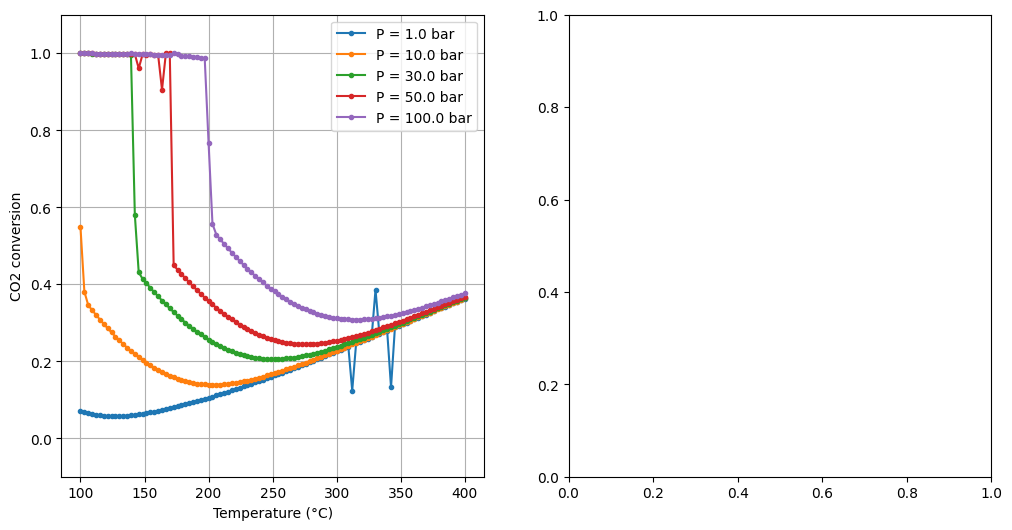

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for pp in range(len(p)):
    
    ax[0].plot(T-273.15, X_CO2[pp], label='P = %.1f bar' % (p[pp] / 1e5), marker='o', markersize=3)

ax[0].set_xlabel('Temperature (°C)')
ax[0].set_ylabel('CO2 conversion')
ax[0].legend()
ax[0].grid()
ax[0].set_ylim(-0.1, 1.1)
plt.show()

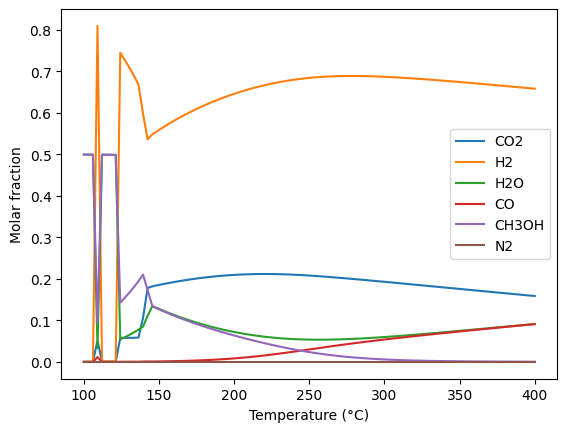

In [96]:
plt.plot(T-273.15, x_eq[2, :, 0], label='CO2')
plt.plot(T-273.15, x_eq[2, :, 1], label='H2')
plt.plot(T-273.15, x_eq[2, :, 2], label='H2O')
plt.plot(T-273.15, x_eq[2, :, 3], label='CO')
plt.plot(T-273.15, x_eq[2, :, 4], label='CH3OH')
plt.plot(T-273.15, x_eq[2, :, 5], label='N2')

plt.xlabel('Temperature (°C)')
plt.ylabel('Molar fraction')
plt.legend()
plt.show()

# plot K0 from eq comp and free Gibbs energy

In [73]:
K0_R1_fg = np.zeros_like(T)
K0_R2_fg = np.zeros_like(T)
K0_R3_fg = np.zeros_like(T)

for i in range(len(T)):

    K0_R1_fg[i] = K0_CO_to_MeOH(T[i])
    K0_R2_fg[i] = K0_CO2_to_MeOH(T[i])
    K0_R3_fg[i] = K0_WGS(T[i])

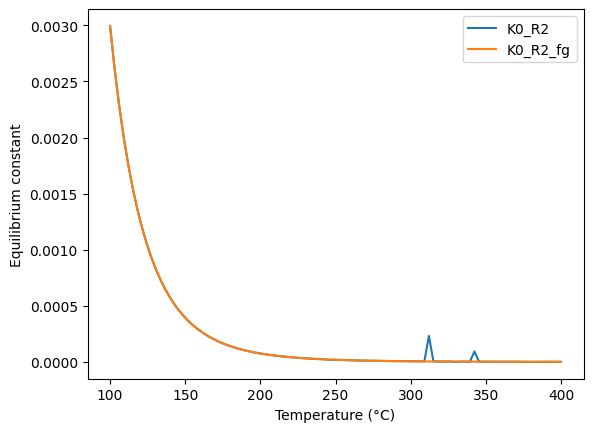

In [74]:
#plt.plot(T-273.15, K0_R1[0], label='K0_R1')
plt.plot(T-273.15, K0_R2[0], label='K0_R2')
#plt.plot(T-273.15, K0_R3[0], label='K0_R3')
#plt.plot(T-273.15, K0_R1_fg, label='K0_R1_fg')
plt.plot(T-273.15, K0_R2_fg, label='K0_R2_fg')
#plt.plot(T-273.15, K0_R3_fg, label='K0_R3_fg')

plt.xlabel('Temperature (°C)')
plt.ylabel('Equilibrium constant')
plt.legend()
plt.show()

# Percentage deviation

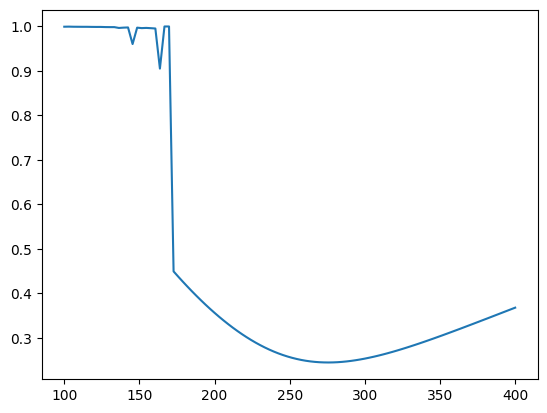

In [75]:
plt.plot(T-273.15, X_CO2[3, :], label='CO2 conversion')

In [76]:
X_CO2[3, :]

array([0.99947074, 0.99966188, 0.99940377, 0.9993353 , 0.99925499,
       0.99925299, 0.99906892, 0.99895968, 0.99899212, 0.99867211,
       0.99855792, 0.99854375, 0.99668178, 0.99740418, 0.99782541,
       0.96050036, 0.99734334, 0.99631957, 0.9967663 , 0.99618022,
       0.99547167, 0.90530603, 0.99999186, 1.        , 0.4494184 ,
       0.43790208, 0.42666114, 0.41570124, 0.4050278 , 0.39465642,
       0.38457313, 0.37477577, 0.36532272, 0.3562064 , 0.34738904,
       0.33891066, 0.33077299, 0.32295462, 0.31553963, 0.30844276,
       0.3017219 , 0.29535977, 0.28936736, 0.28375384, 0.27852394,
       0.273666  , 0.26919774, 0.26511444, 0.26141255, 0.25811483,
       0.25517344, 0.25262011, 0.25040383, 0.24858547, 0.24711809,
       0.24599874, 0.24522836, 0.24479491, 0.24465068, 0.24482614,
       0.24526916, 0.24601403, 0.24701287, 0.24826854, 0.24976019,
       0.25145024, 0.25334727, 0.25546966, 0.25771377, 0.26014811,
       0.26273668, 0.26545971, 0.26831601, 0.2712943 , 0.27436

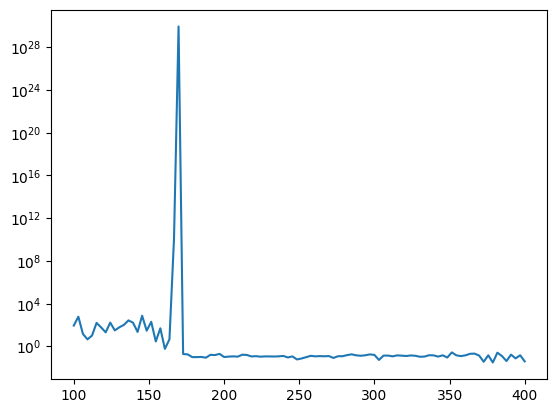

In [91]:
sum_K_dev = np.abs((K0_R1[3] - K0_R1_fg) / K0_R1_fg * 100) + np.abs((K0_R2[3] - K0_R2_fg) / K0_R2_fg * 100) + np.abs((K0_R3[3] - K0_R3_fg) / K0_R3_fg * 100)
plt.plot(T-273.15, sum_K_dev, label='Sum of K deviations')
plt.yscale('log')


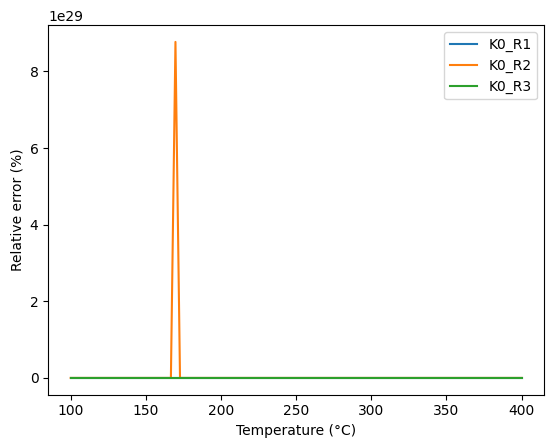

In [ ]:
plt.plot(T-273.15, np.abs((K0_R1[0] - K0_R1_fg) / K0_R1_fg * 100), label='K0_R1')
plt.plot(T-273.15, np.abs((K0_R2[3] - K0_R2_fg) / K0_R2_fg * 100), label='K0_R2')
plt.plot(T-273.15, np.abs((K0_R3[0] - K0_R3_fg) / K0_R3_fg * 100), label='K0_R3')

plt.xlabel('Temperature (°C)')
plt.ylabel('Relative error (%)')
plt.legend()
#plt.ylim(0, 100)
plt.show()

In [46]:
vapor_frac = np.zeros((len(p), len(T)))

counter = 0

counter_2 = 0

for i in range(len(p)):
    for j in range(len(T)):
        try:
            
            phii_V, Z_V = phi_SRK(n_eq[i, j, :6] / np.sum(n_eq[i, j, :6]), T[j], p[i])
            phii_L, Z_L = phi_SRK(n_eq[i, j, 6:] / np.sum(n_eq[i, j, 6:]), T[j], p[i])
            
            # was carried up
            if Z_L > Z_V:
                vapor_frac[i, j] = np.sum(n_eq[i, j, 6:]) / (np.sum(n_eq[i, j, :6]) + np.sum(n_eq[i, j, 6:]))
            else:
                vapor_frac[i, j] = np.sum(n_eq[i, j, :6]) / (np.sum(n_eq[i, j, :6]) + np.sum(n_eq[i, j, 6:]))

            if i == 4:

                counter_2 += 1

        except:

            # check if not any nan in n_eq[i, j, :6]

            if not np.any(np.isnan(n_eq[i, j, :6])):
                phii, Z = phi_SRK(n_eq[i, j, :6] / np.sum(n_eq[i, j, :6]), T[j], p[i])

                if i == 4:
                    #print("T", T[j]-273.15)
                    #print("Z", Z)

                    counter += 1
                #print("T")

                    print(j, Z)


            #phii, Z = phi_SRK(n_eq[i, j, :6] / np.sum(n_eq[i, j, :6]), T[j], p[i])
            
            #phii, Z = phi_SRK(n_eq[i, j, :6] / np.sum(n_eq[i, j, :6]), T[j], p[i]

            if Z < 0.2:

                if i == 0:

                    print("T", T[j]-273.15)
                vapor_frac[i, j] = 0
                

        #print(Z_L, Z_V, T[j])
        
        if i == 4:
            #print("T", T[j]-273.15)

            #if Z_L > 0.5 or Z_V > 0.5:
            #    print("T", T[j]-273.15)
            #    print("Z_L", Z_L)
            #    print("Z_V", Z_V)
            pass


        

0 0.13432352898217953
1 0.1337760510989618
2 0.13324939652129492
3 0.13274379427735755
4 0.13225993730057062
5 0.13179752957003987
6 0.13135685314713952
7 0.13095105820743752
8 0.13054078733665025
9 0.13016463748859608
10 0.12981357444774144
11 0.12948398465990885
12 0.12917784620312
14 0.1286396167364534
15 0.12840448895586143
16 0.12819677240479194
17 0.1280161470649291
18 0.12786291162705382
19 0.12773868984252956
20 0.12764462048643171
21 0.1275805847063096
22 0.1275511187316966
23 0.12755568671601555
26 0.1278057101008961
27 0.1279773738441495
28 0.1281989605448979
29 0.12847685265728429
30 0.1288158023948103
35 0.9386760002647994
36 0.9456437306916372
37 0.9520112749514771
38 0.9578433393050609
39 0.9632032880089012
40 0.9681263678073131
41 0.9726659311662662
42 0.9768588990463041
43 0.9807224541592481
44 0.9843009737475346
45 0.9876131094317706
46 0.9906807249590432
47 0.9935274926943827
48 0.9961659890485153
49 0.9986146472974062
50 1.0008893711278963
51 1.0029997985039076
52 1

/var/folders/yw/rfzdpk2n2xj66f7rqc4328wm0000gn/T/ipykernel_81114/3091616216.py:12: RuntimeWarning: invalid value encountered in divide
  phii_L, Z_L = phi_SRK(n_eq[i, j, 6:] / np.sum(n_eq[i, j, 6:]), T[j], p[i])


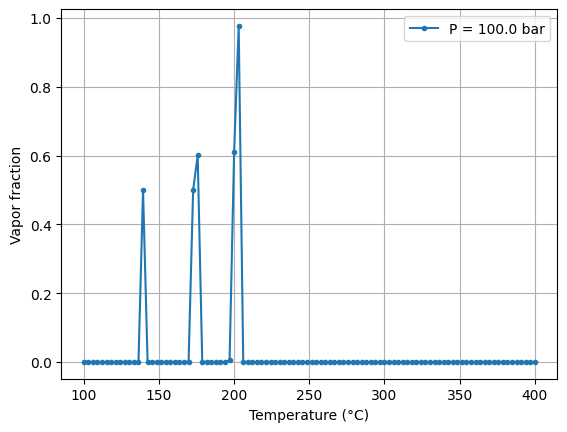

In [47]:
plt.plot(T-273.15, vapor_frac[-1], label='P = %.1f bar' % (p[-1] / 1e5), marker='o', markersize=3)
plt.xlabel('Temperature (°C)')
plt.ylabel('Vapor fraction')
plt.legend()
plt.grid()
plt.show()

In [48]:
n_eq[-1, 0, :6] / np.sum(n_eq[-1, 0, :6])

array([2.17780117e-04, 6.55512787e-04, 4.99563353e-01, 1.08681745e-06,
       4.99562267e-01, 1.99912453e-10])

In [49]:
phii, Z = phi_SRK(n_eq[-1, 0, :6] / np.sum(n_eq[-1, 0, :6]), T[0], p[-1])

print("Z", Z)
print("phii", phii)

Z 0.13432352898217953
phii [2.55272141e+01 1.40733324e+02 1.36602301e-02 6.27277113e+01
 4.44142833e-02 6.47665115e+01]


In [50]:
n_eq[-1, 5, 6:] / np.sum(n_eq[-1, 5, 6:])

/var/folders/yw/rfzdpk2n2xj66f7rqc4328wm0000gn/T/ipykernel_81114/793474370.py:1: RuntimeWarning: invalid value encountered in divide
  n_eq[-1, 5, 6:] / np.sum(n_eq[-1, 5, 6:])


array([nan, nan, nan, nan, nan, nan])

In [51]:
vapor_frac[-1,25]

0.6005348084995727

In [52]:
n_eq[-1, 25, :6] / np.sum(n_eq[-1, 25, :6])

array([1.02006696e-03, 3.08646002e-03, 4.97946736e-01, 1.31301629e-05,
       4.97933606e-01, 1.99586721e-10])

In [53]:
n_eq[-1, 25, 6:] / np.sum(n_eq[-1, 25, 6:])

array([1.02006694e-03, 3.08645998e-03, 4.97946736e-01, 1.31301812e-05,
       4.97933606e-01, 1.99586721e-10])

In [54]:
counter, counter_2

(93, 7)

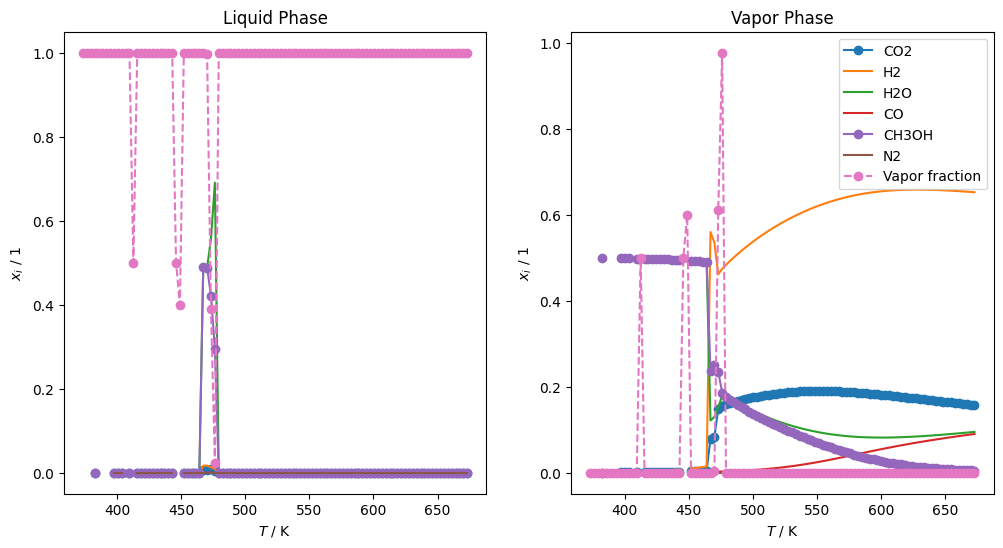

In [55]:
# plot vapor phase conc
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for pp in range(len(p)):

ax[1].plot(T, x_eq[-1, :, 0], label='CO2', marker='o')
ax[1].plot(T, x_eq[-1, :, 1], label='H2')
ax[1].plot(T, x_eq[-1, :, 2], label='H2O')
ax[1].plot(T, x_eq[-1, :, 3], label='CO')
ax[1].plot(T, x_eq[-1, :, 4], label='CH3OH', marker='o')
ax[1].plot(T, x_eq[-1, :, 5], label='N2')
ax[1].plot(T, vapor_frac[-1], label='Vapor fraction', marker='o', linestyle='--')

ax[0].plot(T, x_eq[-1, :, 6], label='CO2', marker='o')
ax[0].plot(T, x_eq[-1, :, 7], label='H2')
ax[0].plot(T, x_eq[-1, :, 8], label='H2O')
ax[0].plot(T, x_eq[-1, :, 9], label='CO')
ax[0].plot(T, x_eq[-1, :, 10], label='CH3OH', marker='o')
ax[0].plot(T, x_eq[-1, :, 11], label='N2')
ax[0].plot(T, 1-vapor_frac[-1], label='Liquid fraction', marker='o', linestyle='--')

ax[1].set_xlabel('$T$ / K')
ax[1].set_ylabel('$x_i$ / 1')
ax[1].legend()

ax[0].set_title('Liquid Phase')
ax[1].set_title('Vapor Phase')
ax[0].set_xlabel('$T$ / K')
ax[0].set_ylabel('$x_i$ / 1')

plt.show()

In [56]:
vapor_frac[3, 21]

0.25091116102086575

In [57]:
'''f_i = np.zeros((len(p), len(T), 12))
f_dev = np.zeros((len(p), len(T), 6))
x_dev = np.zeros((len(p), len(T), 6))

phii = np.zeros((len(p), len(T), 12))

for i in range(len(p)):
    for j in range(len(T)):
        try:

            if not np.any(x_eq[i, j, 6:] == 0):

                phii_V, Z_V = phi_SRK(x_eq[i, j, :6], T[j], p[i])
                phii_L, Z_L = phi_SRK(x_eq[i, j, 6:], T[j], p[i])

                if Z_L > Z_V:

                # change positiion of x_eq (first 6 with last 6)
                    x_eq[i, j, :] = np.concatenate((x_eq[i, j, 6:], x_eq[i, j, :6]))

            f_i[i, j, :] = x_eq[i, j, :] * phi_SRK_VLE(x_eq[i, j, :], T[j], p[i])



            phii[i, j, :] = phi_SRK_VLE(x_eq[i, j, :], T[j], p[i])
            f_V = f_i[i, j, :6]
            f_L = f_i[i, j, 6:]
            f_dev[i, j, :] = (f_V - f_L) / f_V * 100

            x_L = x_eq[i, j, 6:]
            x_V = x_eq[i, j, :6]

            # check if x_L contains zeros
            if np.any(x_L == 0):
                x_dev[i, j, :] = np.nan
            else:
                x_dev[i, j, :] = (x_L - x_V) / x_L * 100

        except TypeError:
            f_i[i, j, :] = np.nan'''

'f_i = np.zeros((len(p), len(T), 12))\nf_dev = np.zeros((len(p), len(T), 6))\nx_dev = np.zeros((len(p), len(T), 6))\n\nphii = np.zeros((len(p), len(T), 12))\n\nfor i in range(len(p)):\n    for j in range(len(T)):\n        try:\n\n            if not np.any(x_eq[i, j, 6:] == 0):\n\n                phii_V, Z_V = phi_SRK(x_eq[i, j, :6], T[j], p[i])\n                phii_L, Z_L = phi_SRK(x_eq[i, j, 6:], T[j], p[i])\n\n                if Z_L > Z_V:\n\n                # change positiion of x_eq (first 6 with last 6)\n                    x_eq[i, j, :] = np.concatenate((x_eq[i, j, 6:], x_eq[i, j, :6]))\n\n            f_i[i, j, :] = x_eq[i, j, :] * phi_SRK_VLE(x_eq[i, j, :], T[j], p[i])\n\n\n\n            phii[i, j, :] = phi_SRK_VLE(x_eq[i, j, :], T[j], p[i])\n            f_V = f_i[i, j, :6]\n            f_L = f_i[i, j, 6:]\n            f_dev[i, j, :] = (f_V - f_L) / f_V * 100\n\n            x_L = x_eq[i, j, 6:]\n            x_V = x_eq[i, j, :6]\n\n            # check if x_L contains zeros\n    

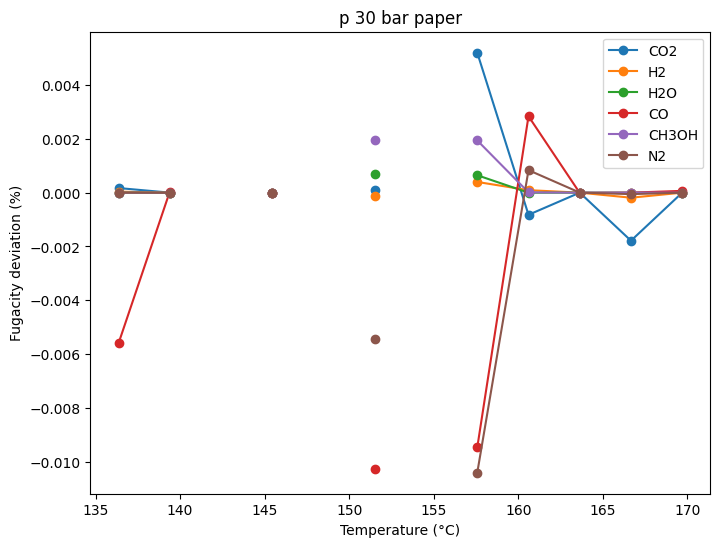

In [58]:
# plot liquid vs vapor fugacity
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

#for pp in range(2, 3):
    
ax.plot(T-273.15, f_dev[3, :, 0], label='CO2', marker='o')
ax.plot(T-273.15, f_dev[3, :, 1], label='H2', marker='o')
ax.plot(T-273.15, f_dev[3, :, 2], label='H2O', marker='o')
ax.plot(T-273.15, f_dev[3, :, 3], label='CO', marker='o')
ax.plot(T-273.15, f_dev[3, :, 4], label='CH3OH', marker='o')
ax.plot(T-273.15, f_dev[3, :, 5], label='N2', marker='o')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Fugacity deviation (%)')
ax.legend()
plt.title('p 30 bar paper')
plt.show()

In [ ]:
for i in range(len(T)):
    if X_CO2[0, i] < 0.99:
        print('T = %.2f °C, X_CO2 = %.2f' % (T[i]-273.15, X_CO2[0, i]))
        print('x_eq =', x_eq[0, i])
        x_PhSt = x_eq[0, i]
        break

T = 189.85 °C, X_CO2 = 0.98
x_eq = [2.54666757e-03 4.40960786e-01 2.47210280e-02 3.40496935e-04
 2.83263300e-01 2.48167722e-01 9.01069712e-04 6.30632284e-02
 1.00673387e-01 6.87692972e-05 7.78590816e-01 5.67027292e-02]


In [ ]:
print(x_eq[0, 0, :])

[2.54666757e-03 4.40960786e-01 2.47210280e-02 3.40496935e-04
 2.83263300e-01 2.48167722e-01 9.01069712e-04 6.30632284e-02
 1.00673387e-01 6.87692972e-05 7.78590816e-01 5.67027292e-02]


In [ ]:
print('x_PhSt =', x_PhSt)

x_PhSt = [2.54666757e-03 4.40960786e-01 2.47210280e-02 3.40496935e-04
 2.83263300e-01 2.48167722e-01 9.01069712e-04 6.30632284e-02
 1.00673387e-01 6.87692972e-05 7.78590816e-01 5.67027292e-02]


In [ ]:
w = np.random.dirichlet(np.ones(6), size=10)

In [ ]:
T = np.linspace(100, 250, 100) + 273.15
z_ref = x_eq

In [ ]:
z_ref.shape

(1, 20, 12)

In [ ]:
min_tpd_val = np.zeros((len(w), len(T)))
TPD_vals = np.zeros((len(w), len(T)))
x = np.zeros((100, 6))
for i in range(len(w)):
    for j in range(len(T)):
        min_tpd_val[i, j], x[j, :] = min_tpd(w[i], z_ref[0, j, :], T[j], 50e5, phase="liquid")
        #TPD_vals[i, j], _ = min_TPD(w[i], z_ref[0, j, :], T[j], 100e5)

TypeError: min_tpd() got an unexpected keyword argument 'phase'

In [ ]:
for i in range(len(T)):
    for j in range(len(w)):
        if min_tpd_val[j, i] < 0:
            print('T = %.2f °C, min_tpd = %.2f' % (T[i]-273.15, min_tpd_val[j, i]))            # print TPD
            #print('TPD =', TPD_vals[j, i], 'T', T[i]-273.15)
            #print('x =', x[j,:])

T = 145.45 °C, min_tpd = -0.01
T = 145.45 °C, min_tpd = -0.01
T = 145.45 °C, min_tpd = -0.01
T = 145.45 °C, min_tpd = -0.01
T = 145.45 °C, min_tpd = -0.01
T = 145.45 °C, min_tpd = -0.01
T = 145.45 °C, min_tpd = -0.01
T = 145.45 °C, min_tpd = -0.01
T = 145.45 °C, min_tpd = -0.01
T = 145.45 °C, min_tpd = -0.01
T = 146.97 °C, min_tpd = -0.04
T = 146.97 °C, min_tpd = -0.04
T = 146.97 °C, min_tpd = -0.04
T = 146.97 °C, min_tpd = -0.04
T = 146.97 °C, min_tpd = -0.04
T = 146.97 °C, min_tpd = -0.04
T = 146.97 °C, min_tpd = -0.04
T = 146.97 °C, min_tpd = -0.04
T = 146.97 °C, min_tpd = -0.04
T = 146.97 °C, min_tpd = -0.04
T = 148.48 °C, min_tpd = -0.06
T = 148.48 °C, min_tpd = -0.06
T = 148.48 °C, min_tpd = -0.06
T = 148.48 °C, min_tpd = -0.06
T = 148.48 °C, min_tpd = -0.06
T = 148.48 °C, min_tpd = -0.06
T = 148.48 °C, min_tpd = -0.06
T = 148.48 °C, min_tpd = -0.06
T = 148.48 °C, min_tpd = -0.06
T = 148.48 °C, min_tpd = -0.06
T = 150.00 °C, min_tpd = -0.09
T = 150.00 °C, min_tpd = -0.09
T = 150.

In [ ]:
stop

NameError: name 'stop' is not defined

In [ ]:
for i in range(len(T)):
    for j in range(len(w)):
        if min_tpd_val[j, i] < 0:
            print('T = %.2f °C, min_tpd = %.2f' % (T[i]-273.15, min_tpd_val[j, i]))
            # print TPD
            #print('TPD =', TPD_vals[j, i], 'T', T[i]-273.15)
            #print('x =', x[j,:])

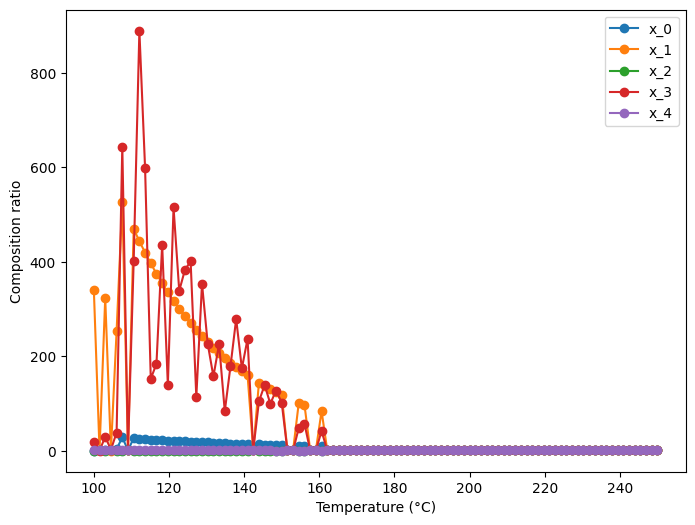

In [ ]:
ratio_comps = np.zeros((len(T), 6))
for i in range(len(T)):
    ratio_comps[i, :] = x[i, :] / x_eq[0, i]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for i in range(5):
    ax.plot(T-273.15, ratio_comps[:, i], label='x_%d' % i, marker='o')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Composition ratio')
ax.legend()

plt.show()

In [ ]:
tpd_m = []

for j in range(len(T)):
    _, tpd_m.append(tpd_minimas(10, z_ref[0, j, :], T[j], 100e5, eos, 'L', 'V'))

In [ ]:
tpd_m_vals = np.zeros((len(T)))
for i in range(len(T)):
    tpd_m_vals[i] = min(tpd_m[i][-1])

In [ ]:
T-273.15

array([100.        , 101.51515152, 103.03030303, 104.54545455,
       106.06060606, 107.57575758, 109.09090909, 110.60606061,
       112.12121212, 113.63636364, 115.15151515, 116.66666667,
       118.18181818, 119.6969697 , 121.21212121, 122.72727273,
       124.24242424, 125.75757576, 127.27272727, 128.78787879,
       130.3030303 , 131.81818182, 133.33333333, 134.84848485,
       136.36363636, 137.87878788, 139.39393939, 140.90909091,
       142.42424242, 143.93939394, 145.45454545, 146.96969697,
       148.48484848, 150.        , 151.51515152, 153.03030303,
       154.54545455, 156.06060606, 157.57575758, 159.09090909,
       160.60606061, 162.12121212, 163.63636364, 165.15151515,
       166.66666667, 168.18181818, 169.6969697 , 171.21212121,
       172.72727273, 174.24242424, 175.75757576, 177.27272727,
       178.78787879, 180.3030303 , 181.81818182, 183.33333333,
       184.84848485, 186.36363636, 187.87878788, 189.39393939,
       190.90909091, 192.42424242, 193.93939394, 195.45

In [ ]:
for i in range(len(tpd_m_vals)):
    if tpd_m_vals[i] < -1e-5:
        print('T = %.2f °C, min_tpd = %.2f' % (T[i]-273.15, tpd_m_vals[i]))

T = 100.00 °C, min_tpd = -0.06
T = 118.18 °C, min_tpd = -0.03
T = 124.24 °C, min_tpd = -0.02
T = 128.79 °C, min_tpd = -0.01
T = 142.42 °C, min_tpd = -0.09
T = 151.52 °C, min_tpd = -0.62
T = 153.03 °C, min_tpd = -0.62
T = 157.58 °C, min_tpd = -0.60
T = 159.09 °C, min_tpd = -0.59
T = 162.12 °C, min_tpd = -0.58
T = 163.64 °C, min_tpd = -0.57
T = 165.15 °C, min_tpd = -0.56
T = 166.67 °C, min_tpd = -0.56
T = 168.18 °C, min_tpd = -0.55
T = 169.70 °C, min_tpd = -0.54
T = 171.21 °C, min_tpd = -0.53
T = 172.73 °C, min_tpd = -0.52
T = 174.24 °C, min_tpd = -0.51
T = 175.76 °C, min_tpd = -0.50
T = 177.27 °C, min_tpd = -0.49
T = 178.79 °C, min_tpd = -0.48
T = 180.30 °C, min_tpd = -0.46
T = 181.82 °C, min_tpd = -0.45
T = 183.33 °C, min_tpd = -0.44
T = 184.85 °C, min_tpd = -0.43
T = 186.36 °C, min_tpd = -0.42
T = 187.88 °C, min_tpd = -0.40
T = 189.39 °C, min_tpd = -0.39
T = 190.91 °C, min_tpd = -0.38
T = 192.42 °C, min_tpd = -0.36
T = 193.94 °C, min_tpd = -0.35
T = 195.45 °C, min_tpd = -0.34
T = 196.

In [ ]:
tpd_m[0][-1]

array([-5.59952760e-02, -6.27053627e-08, -5.59952760e-02, -5.59952760e-02,
       -5.59952760e-02, -5.59952760e-02, -5.59952760e-02, -5.59952760e-02,
       -5.59952760e-02, -5.59952760e-02])

In [ ]:
for j in range(len(T)):
    for i in range(len(w)):
        if tpd_m[i, j] > 1e-5:
            print('T = %.2f °C', T[j]-273.15)
            print('tpd_m =', tpd_m[i, j])

TypeError: list indices must be integers or slices, not tuple